In [1]:
import scanpy as sc
import squidpy as sq
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import anndata as ad
import dill
import h5py
import os
from typing import Dict, List, Tuple, Optional, Union
import json
import gc
from scipy import sparse

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/anndata/__init__.py:44: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  retur

In [2]:
from skimage import segmentation, draw, io
from skimage.filters import gaussian, sobel
from skimage.color import rgb2gray
from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler
from scipy import ndimage as ndi
from matplotlib.colors import ListedColormap, to_rgb

In [3]:
from ssgsea import _get_geneset_distance, ssgsea_output_statistics

In [12]:
BASE_PATH = Path('/auto/brno2/home/luciakostialova/Master_thesis/10xVisium/BRCA1/')
data = sq.read.visium(BASE_PATH, counts_file='Visium_Human_Breast_Cancer_filtered_feature_bc_matrix.h5')
library_id='Visium_Human_Breast_Cancer'
data

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 4898 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [5]:
pwd

'/auto/brno2/home/luciakostialova/Thesis'

In [6]:
ssgsea_out = pd.read_csv('/auto/brno2/home/luciakostialova/Thesis/BRCA1_zscore.csv', sep=',', index_col=0)
ssgsea_out = ssgsea_out.T
ssgsea_out.index = ssgsea_out.index.str.replace(".", "-", regex=False)

In [7]:
ssgsea = ad.AnnData(ssgsea_out)
ssgsea.obs_names = ssgsea_out.index
ssgsea.var_names = ssgsea_out.columns

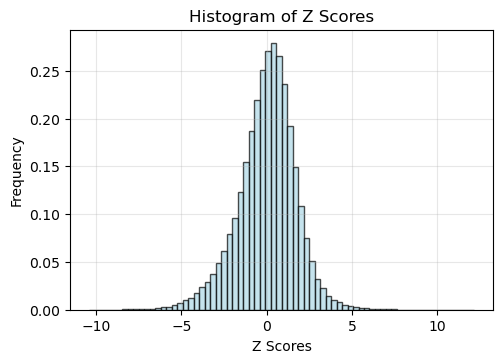

In [8]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(ssgsea.X.flatten(), bins=70, alpha=0.7, color='lightblue', edgecolor='black', density=True)
plt.xlabel('Z Scores')
plt.ylabel('Frequency')
plt.title('Histogram of Z Scores')
plt.grid(True, alpha=0.3)

In [9]:
scaler = MinMaxScaler()

In [16]:
min_counts = np.expm1(7.2).astype("int")
max_counts = np.expm1(11).astype("int")
min_cells = np.expm1(6.8).astype("int")

# Filtering genes and cells
sc.pp.filter_genes(data, min_cells=min_cells)
sc.pp.filter_cells(data, min_counts=min_counts)
sc.pp.filter_cells(data, max_counts=max_counts)

In [24]:
ssgsea.obs

""
AAACAACGAATAGTTC-1
AAACAAGTATCTCCCA-1
AAACAATCTACTAGCA-1
AAACACCAATAACTGC-1
AAACAGAGCGACTCCT-1
...
TTGTTTCACATCCAGG-1
TTGTTTCATTAGTCTA-1
TTGTTTCCATACAACT-1
TTGTTTGTATTACACG-1


In [25]:
agc = AgglomerativeClustering(n_clusters=20, metric='correlation', linkage='complete')
cluster_labels = agc.fit_predict(ssgsea.X)
        
data.obs['clusters'] = cluster_labels
data.obs['clusters'] = data.obs['clusters'].astype('category')   

/auto/brno2/home/luciakostialova/masters_env/lib/python3.12/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


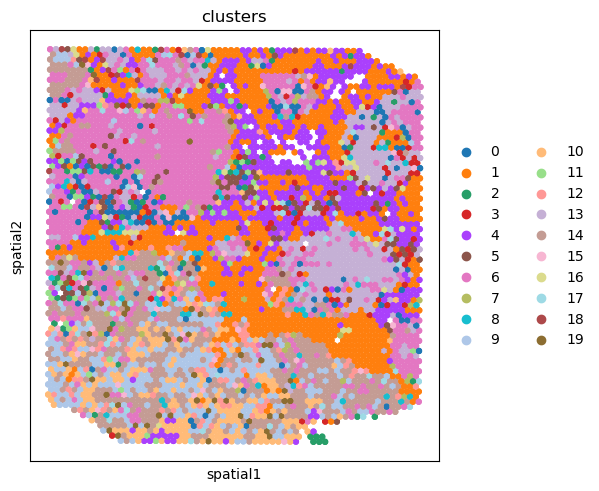

In [26]:
sq.pl.spatial_scatter(data, color="clusters", size=50, shape=None)

Minimum distance: 0.000000
Maximum distance: 1.941383
Mean distance: 0.987200
Median distance: 0.986166
Standard deviation: 0.386673


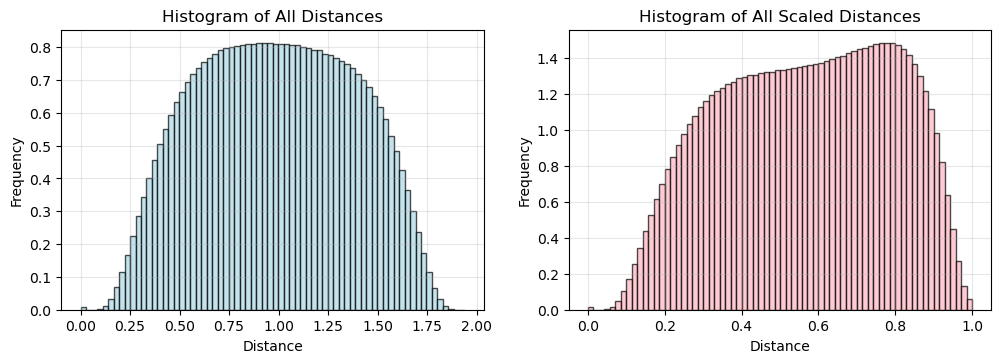

In [45]:
ssgsea_dist = pdist(ssgsea.X, 'cosine')
ssgsea_dist = squareform(ssgsea_dist)
ssgsea_dist_scaled = scaler.fit_transform(ssgsea_dist)

distances = ssgsea_dist.flatten()
scaled_distances = ssgsea_dist_scaled.flatten()

# print(f"Distance matrix shape: {distance_matrix.shape}")
# print(f"Total elements: {distance_matrix.size}")
# print(f"Non-zero elements: {np.count_nonzero(distance_matrix)}")
print(f"Minimum distance: {distances.min():.6f}")
print(f"Maximum distance: {distances.max():.6f}")
print(f"Mean distance: {distances.mean():.6f}")
print(f"Median distance: {np.median(distances):.6f}")
print(f"Standard deviation: {distances.std():.6f}")

# Create histogram
plt.figure(figsize=(12, 8))

# Plot 1: Histogram of all non-zero distances
plt.subplot(2, 2, 1)
plt.hist(distances, bins=70, alpha=0.7, color='lightblue', edgecolor='black', density=True)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Histogram of All Distances')
plt.grid(True, alpha=0.3)

# Plot 2: Density plot
plt.subplot(2, 2, 2)
plt.hist(scaled_distances, bins=70, alpha=0.7, color='lightpink', edgecolor='black', density=True)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Histogram of All Scaled Distances')
plt.grid(True, alpha=0.3)


In [ ]:
def clustering(adata, metric: str = 'correlation', linkage: str='complete', x_pca: bool=False):
    scaler = MinMaxScaler()
    
    agc = AgglomerativeClustering(n_clusters=20, metric=metric, linkage=linkage)
    if x_pca:
        cluster_labels = agc.fit_predict(adata.obsm['X_pca'])
        dist = pdist(adata.obsm['X_pca'], metric=metric)
        scaled_dist = scaler.fit_transform(squareform(dist))
    else:
        cluster_labels = agc.fit_predict(adata.X.toarray())
        dist = pdist(adata.X.toarray(), metric=metric)
        scaled_dist = scaler.fit_transform(squareform(dist))
        
    adata.obs['clusters'] = cluster_labels
    adata.obs['clusters'] = adata.obs['clusters'].astype('category')   

    # Flatten the matrix and remove zeros (diagonal elements)
    distances = dist.flatten()
    scaled_distances = scaled_dist.flatten()
    
    # print(f"Distance matrix shape: {distance_matrix.shape}")
    # print(f"Total elements: {distance_matrix.size}")
    # print(f"Non-zero elements: {np.count_nonzero(distance_matrix)}")
    # print(f"Minimum distance: {distances.min():.6f}")
    # print(f"Maximum distance: {distances.max():.6f}")
    # print(f"Mean distance: {distances.mean():.6f}")
    # print(f"Median distance: {np.median(distances):.6f}")
    # print(f"Standard deviation: {distances.std():.6f}")
    
    # Create histogram
    plt.figure(figsize=(12, 8))
    
    # Plot 1: Histogram of all non-zero distances
    plt.subplot(2, 2, 1)
    plt.hist(distances, bins=70, alpha=0.7, color='lightblue', edgecolor='black', density=True)
    plt.xlabel('Distance')
    plt.ylabel('Frequency')
    plt.title('Histogram of All Distances')
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Density plot
    plt.subplot(2, 2, 2)
    plt.hist(scaled_distances, bins=70, alpha=0.7, color='lightpink', edgecolor='black', density=True)
    plt.xlabel('Distance')
    plt.ylabel('Frequency')
    plt.title('Histogram of All Scaled Distances')
    plt.grid(True, alpha=0.3)

    sq.pl.spatial_scatter(adata, color="clusters", size=50, shape=None)